In [2]:
import os
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
!ls /kaggle/input/image-colorization-dataset/data

test_black  test_color	train_black  train_color


In [5]:
class ColorizationDataset(Dataset):
    def __init__(self, gray_dir, color_dir, transform=None):
        self.gray_dir = Path(gray_dir)
        self.color_dir = Path(color_dir)
        self.gray_files = sorted(list(self.gray_dir.glob("*.jpg"))) + sorted(list(self.gray_dir.glob("*.png")))
        self.transform = transform

    def __len__(self):
        return len(self.gray_files)

    def __getitem__(self, idx):
        gray_path = self.gray_files[idx]
        color_path = self.color_dir / gray_path.name

        gray = Image.open(gray_path).convert("L")   # grayscale
        color = Image.open(color_path).convert("RGB")

        if self.transform:
            gray = self.transform(gray)
            color = self.transform(color)

        return gray, color

In [6]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2, 2)

        self.middle = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 3, 1)  # 3 channels for RGB output

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        m = self.middle(self.pool(e3))

        d3 = self.up3(m)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        out = torch.sigmoid(self.final(d1))
        return out

In [7]:
def train_model(model, dataloader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for gray, color in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            gray, color = gray.to(device), color.to(device)
            optimizer.zero_grad()
            output = model(gray)
            loss = criterion(output, color)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(dataloader):.4f}")

In [8]:
def visualize_predictions(model, test_gray_dir, test_color_dir, device, transform, num_samples=20):
    # model.eval()
    gray_files = sorted(list(Path(test_gray_dir).glob("*.jpg")))[:num_samples]
    plt.figure(figsize=(12, num_samples * 3))

    for i, gray_path in enumerate(gray_files):
        gray = Image.open(gray_path).convert("L")
        color_path = Path(test_color_dir) / gray_path.name
        color_gt = Image.open(color_path).convert("RGB")

        gray_tensor = transform(gray).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_color = model(gray_tensor).cpu().squeeze(0)

        pred_color = transforms.ToPILImage()(pred_color)
        gray_disp = transforms.ToPILImage()(gray_tensor.squeeze(0))

        # Display
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(gray_disp, cmap="gray")
        plt.title("Grayscale Input")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(pred_color)
        plt.title("Predicted Color")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(color_gt)
        plt.title("Ground Truth")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def main():
    data_root = Path("/kaggle/input/image-colorization-dataset/data")

    train_gray = data_root / "train_black"
    train_color = data_root / "train_color"

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])

    train_dataset = ColorizationDataset(train_gray, train_color, transform)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet().to(device)
    criterion = nn.L1Loss()  # smooth color differences
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    train_model(model, train_loader, optimizer, criterion, device, epochs=100)

    torch.save(model.state_dict(), "unet_colorization.pth")
    print("Training completed. Model saved as 'unet_colorization.pth'.")

In [ ]:
if __name__ == "__main__":
    main()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

weights_path = "/kaggle/input/unetweights/unet_colorization.pth"  
model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

UNet(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [10]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

test_gray_dir = Path("/kaggle/input/image-colorization-dataset/data/test_black")
test_color_dir = Path("/kaggle/input/image-colorization-dataset/data/test_color")

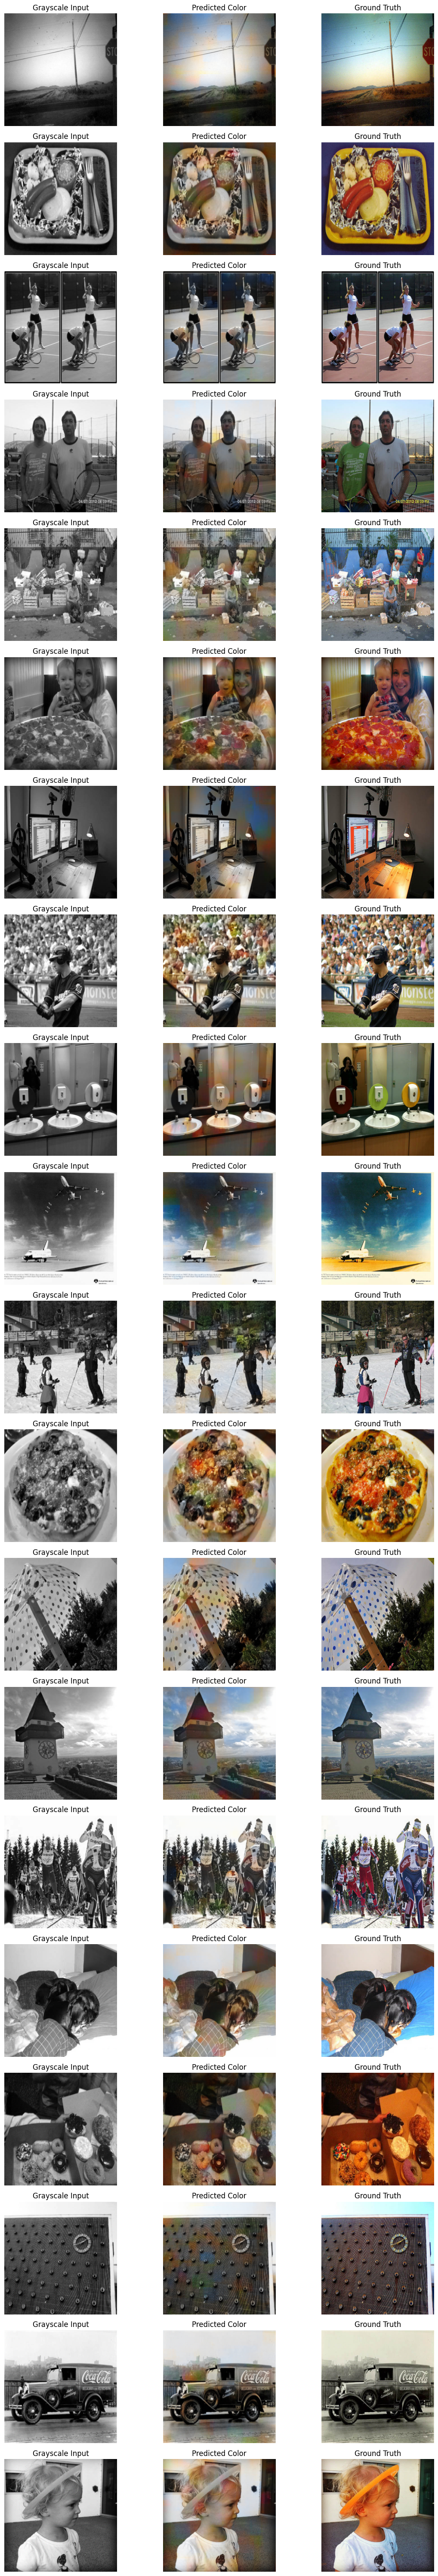

In [11]:
visualize_predictions(model, test_gray_dir, test_color_dir, device,transform)